# Out-of-Zone Injection Modeling with NeqSim

This notebook demonstrates NeqSim's capabilities for modeling out-of-zone injection risks
in water, gas, and CO2 injection wells. It covers:

1. **Multi-zone injection allocation** — rate distribution across target and thief zones
2. **Fracture containment** — barrier stress contrast checks
3. **Thermal stress effects** — cold-water fracture pressure reduction
4. **Annular leakage** — behind-casing flow through cement/micro-annulus
5. **Cement degradation** — CO2 carbonation of wellbore cement over time
6. **Multi-compartment reservoir** — inter-zone pressure communication
7. **Conformance monitoring** — Hall plot analysis and diagnostics

In [2]:
# Import NeqSim - Direct Java Access via devtools (local dev mode)
import sys, os
# In VS Code notebooks, CWD is the workspace root — use that as project root
sys.path.insert(0, os.path.join(os.getcwd(), "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_init(project_root=os.getcwd(), recompile=False)
ns = neqsim_classes(ns)
NEQSIM_MODE = "devtools"
print("NeqSim loaded via devtools (local dev mode)")

import jpype
import numpy as np
import matplotlib.pyplot as plt

Classpath:
  1. c:\Users\ESOL\Documents\GitHub\neqsim4\target\classes
  2. c:\Users\ESOL\Documents\GitHub\neqsim4\src\main\resources
  3. c:\Users\ESOL\Documents\GitHub\neqsim4\target\neqsim-3.7.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [3]:
# Import NeqSim Java classes
from neqsim import jneqsim

SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
Stream = jneqsim.process.equipment.stream.Stream
WellFlow = jneqsim.process.equipment.reservoir.WellFlow
AnnularLeakagePath = jneqsim.process.equipment.reservoir.AnnularLeakagePath
MultiCompartmentReservoir = jneqsim.process.equipment.reservoir.MultiCompartmentReservoir
CementDegradationModel = jneqsim.process.equipment.reservoir.CementDegradationModel
InjectionConformanceMonitor = jneqsim.process.equipment.reservoir.InjectionConformanceMonitor

InjectionWellModel = jpype.JClass("neqsim.process.fielddevelopment.reservoir.InjectionWellModel")

print("All classes loaded successfully")

All classes loaded successfully


## 1. Multi-Zone Injection with WellFlow

A commingled injection well injects into both a target sand and a thief zone.
The zones have different injectivity indices (II) and fracture pressures.
We use `WellFlow` in injection mode to model rate allocation.

In [5]:
# Create injection fluid (water at reservoir conditions)
fluid = SystemSrkEos(273.15 + 30.0, 300.0)
fluid.addComponent("water", 1.0)
fluid.setMixingRule("classic")

inj_stream = Stream("injection water", fluid)
inj_stream.setFlowRate(10000.0, "kg/hr")
inj_stream.run()

# Create WellFlow in injection mode
well = WellFlow("INJ-1")
well.setInletStream(inj_stream)
well.setFlowMode(WellFlow.FlowMode.INJECTION)

# Add injection zones: (name, stream, reservoir_pressure_bara, injectivity_index, fracture_pressure_bara)
well.addInjectionZone("Target Sand", inj_stream, 250.0, 1e-3, 350.0)
well.addInjectionZone("Thief Zone", inj_stream, 220.0, 3e-3, 280.0)
well.setTargetZone("Target Sand")
well.setOutletPressure(300.0, "bara")  # BHP for injection

well.run()

efficiency = well.getInjectionEfficiency()
ooz_rate = well.getOutOfZoneRate("kg/hr")

print(f"Injection Efficiency:    {efficiency:.1%}")
print(f"Out-of-Zone Rate:        {ooz_rate:.1f} kg/hr")

# Zone allocation fractions
fractions = well.getZoneAllocationFractions()
n_zones = well.getNumberOfLayers()
print("\nZone Allocation:")
for i in range(n_zones):
    name = str(well.getLayer(i).name)
    print(f"  {name}: {fractions[i]:.1%}")

Injection Efficiency:    18.1%
Out-of-Zone Rate:        124.8 kg/hr

Zone Allocation:
  Target Sand: 18.1%
  Thief Zone: 81.9%


## 2. Fracture Containment Assessment

For each reservoir layer, we check whether the fracture is contained within the zone
by comparing the net pressure (BHP − fracture pressure) against the barrier stress contrast.

$$
\text{Contained if: } (P_{BHP} - P_{frac}) < \sigma_{barrier}
$$

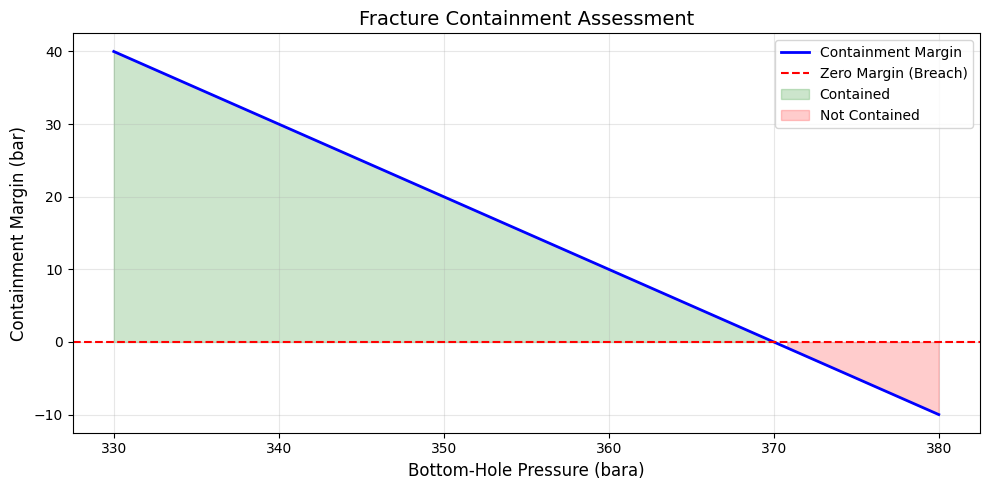

Fracture pressure:       350.0 bara
Barrier stress contrast: 20.0 bar
Max safe BHP:            370.0 bara
Margin at BHP=360:       10.0 bar (contained)
Margin at BHP=375:       -5.0 bar (breached!)


In [6]:
# Create a reservoir layer and set fracture parameters
layer = WellFlow.ReservoirLayer("Target Sand", inj_stream, 250.0, 1e-3)
layer.setFracturePressure(350.0, "bara")
layer.setBarrierStressContrast(20.0, "bara")

# Scan BHP range and check containment
bhp_range = np.linspace(330.0, 380.0, 50)
margins = []
contained = []

for bhp in bhp_range:
    margin = layer.getFractureContainmentMargin(float(bhp))
    is_contained = layer.isFractureContained(float(bhp))
    margins.append(margin)
    contained.append(is_contained)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot margin
ax1.plot(bhp_range, margins, 'b-', linewidth=2, label='Containment Margin')
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1.5, label='Zero Margin (Breach)')
ax1.fill_between(bhp_range, margins, 0,
                 where=[m > 0 for m in margins], alpha=0.2, color='green', label='Contained')
ax1.fill_between(bhp_range, margins, 0,
                 where=[m <= 0 for m in margins], alpha=0.2, color='red', label='Not Contained')

ax1.set_xlabel('Bottom-Hole Pressure (bara)', fontsize=12)
ax1.set_ylabel('Containment Margin (bar)', fontsize=12)
ax1.set_title('Fracture Containment Assessment', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print key values
print(f"Fracture pressure:       {350.0} bara")
print(f"Barrier stress contrast: {20.0} bar")
print(f"Max safe BHP:            {350.0 + 20.0} bara")
print(f"Margin at BHP=360:       {layer.getFractureContainmentMargin(360.0):.1f} bar (contained)")
print(f"Margin at BHP=375:       {layer.getFractureContainmentMargin(375.0):.1f} bar (breached!)")

## 3. Thermal Stress Effects on Fracture Pressure

Cold water injection cools the near-wellbore rock, reducing the minimum horizontal stress
and thus the effective fracture pressure. The thermal stress reduction is:

$$
\Delta\sigma_{th} = \frac{\alpha_T \cdot E \cdot (T_{res} - T_{inj})}{1 - \nu}
$$

where $\alpha_T$ is thermal expansion coefficient, $E$ is Young's modulus, and $\nu$ is Poisson's ratio.

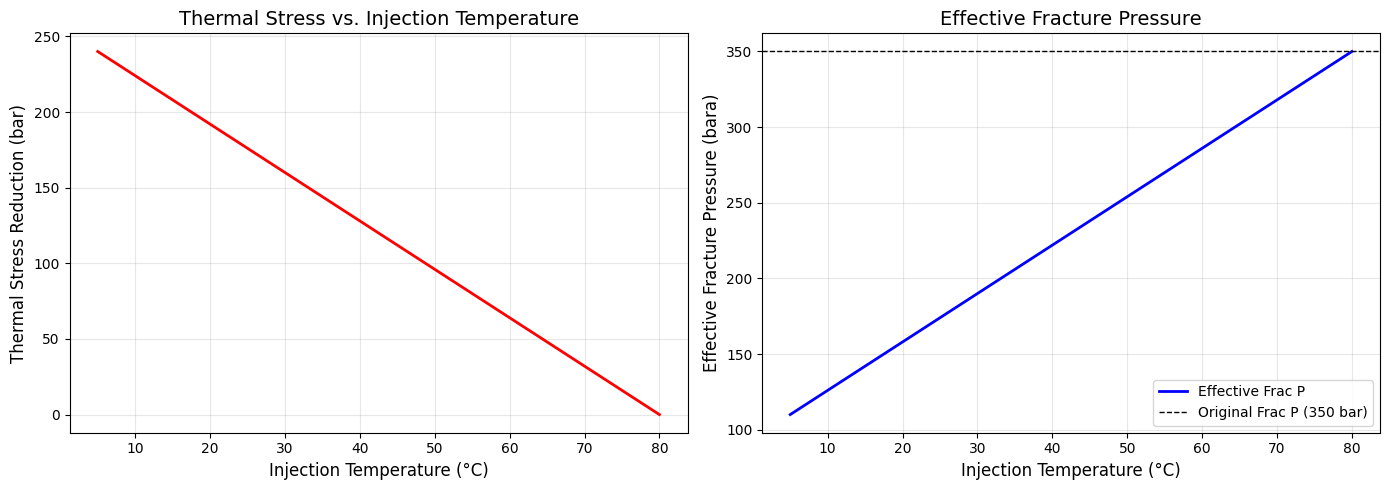

Thermal stress reduction at 30°C injection: 165.5 bar
Effective frac pressure at 30°C injection:  184.5 bara


In [7]:
model = InjectionWellModel()
model.setMaxBHP(350.0, "bara")
model.setFracturePressure(350.0, "bara")
model.setDrainageRadius(500.0)
model.setWellboreRadius(0.1)

# Scan injection temperature from 5 to 80 degC
T_res_K = 273.15 + 80.0  # 80°C reservoir
injection_temps_C = np.linspace(5, 80, 30)
thermal_reductions = []
effective_frac_pressures = []

for T_inj_C in injection_temps_C:
    T_inj_K = 273.15 + T_inj_C
    model.setThermalStressReduction(T_inj_K, T_res_K, 1.2e-5, 20.0)  # alpha, E_GPa
    model.setPoissonsRatio(0.25)

    reduction = model.getThermalStressReduction()
    effective = model.getEffectiveFracturePressure()
    thermal_reductions.append(reduction)
    effective_frac_pressures.append(effective)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(injection_temps_C, thermal_reductions, 'r-', linewidth=2)
ax1.set_xlabel('Injection Temperature (°C)', fontsize=12)
ax1.set_ylabel('Thermal Stress Reduction (bar)', fontsize=12)
ax1.set_title('Thermal Stress vs. Injection Temperature', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(injection_temps_C, effective_frac_pressures, 'b-', linewidth=2, label='Effective Frac P')
ax2.axhline(y=350.0, color='k', linestyle='--', linewidth=1, label='Original Frac P (350 bar)')
ax2.set_xlabel('Injection Temperature (°C)', fontsize=12)
ax2.set_ylabel('Effective Fracture Pressure (bara)', fontsize=12)
ax2.set_title('Effective Fracture Pressure', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Thermal stress reduction at 30°C injection: {thermal_reductions[int(25/75*29)]:.1f} bar")
print(f"Effective frac pressure at 30°C injection:  {effective_frac_pressures[int(25/75*29)]:.1f} bara")

## 4. Annular Leakage Path

Models behind-casing leakage through a micro-annulus gap (cubic law) and
through porous degraded cement (Darcy flow).

We study how leakage rate varies with differential pressure.

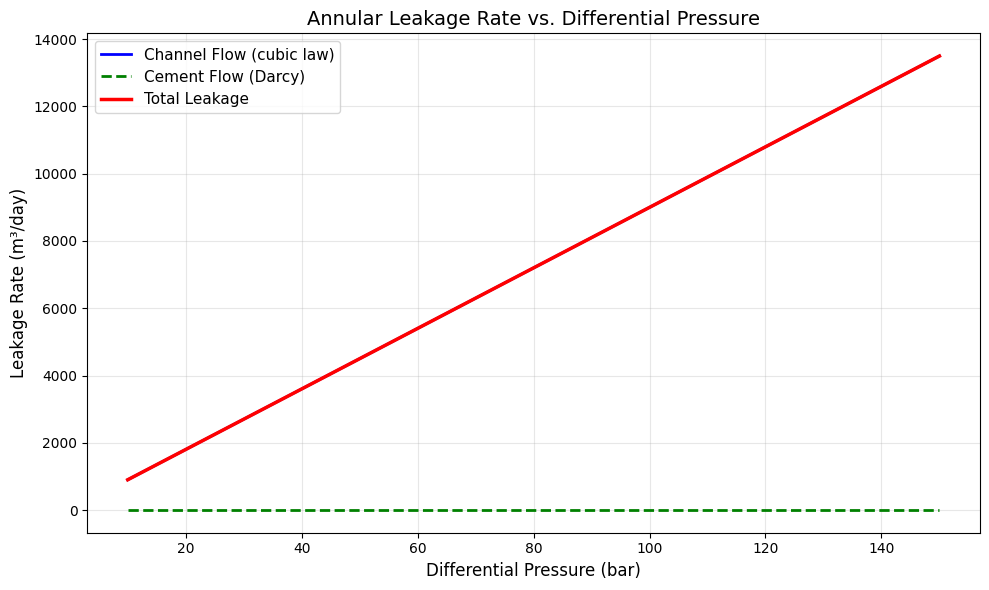

At ΔP = 100 bar:
  Channel leak rate: 9000.0000 m³/day
  Cement leak rate:  0.0017 m³/day
  Total leak rate:   9000.0017 m³/day


In [8]:
leakage = AnnularLeakagePath("cement leak")
leakage.setLeakageMechanism(AnnularLeakagePath.LeakageMechanism.COMBINED)

# Path geometry: top=1500m, bottom=1600m (100m length), width=0.1m, gap=0.5mm
leakage.setPathGeometry(1500.0, 1600.0, 0.10, 0.0005)
leakage.setCementPermeability(0.01, "mD")  # moderately degraded cement
leakage.setCementCrossSectionArea(0.02)  # m2
leakage.setFluidViscosity(0.001)  # Pa.s (water)

# Scan differential pressure
sink_pressure = 250.0  # fixed sink
source_pressures = np.linspace(260.0, 400.0, 30)
channel_rates = []
cement_rates = []
total_rates = []

for p_source in source_pressures:
    leakage.calculate(float(p_source), sink_pressure)
    channel_rates.append(leakage.getChannelLeakageRate("m3/day"))
    cement_rates.append(leakage.getCementLeakageRate("m3/day"))
    total_rates.append(leakage.getTotalLeakageRate("m3/day"))

dp = source_pressures - sink_pressure

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dp, channel_rates, 'b-', linewidth=2, label='Channel Flow (cubic law)')
ax.plot(dp, cement_rates, 'g--', linewidth=2, label='Cement Flow (Darcy)')
ax.plot(dp, total_rates, 'r-', linewidth=2.5, label='Total Leakage')

ax.set_xlabel('Differential Pressure (bar)', fontsize=12)
ax.set_ylabel('Leakage Rate (m³/day)', fontsize=12)
ax.set_title('Annular Leakage Rate vs. Differential Pressure', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"At ΔP = 100 bar:")
leakage.calculate(350.0, 250.0)
print(f"  Channel leak rate: {leakage.getChannelLeakageRate('m3/day'):.4f} m³/day")
print(f"  Cement leak rate:  {leakage.getCementLeakageRate('m3/day'):.4f} m³/day")
print(f"  Total leak rate:   {leakage.getTotalLeakageRate('m3/day'):.4f} m³/day")

## 5. Cement Degradation Under CO2 Exposure

For CCS wells, cement integrity degrades over decades as CO2 carbonates the Portland cement.
The carbonation front advances as:

$$
d(t) = A \sqrt{D_{eff} \cdot t}
$$

We compare three cement types over a 50-year period.

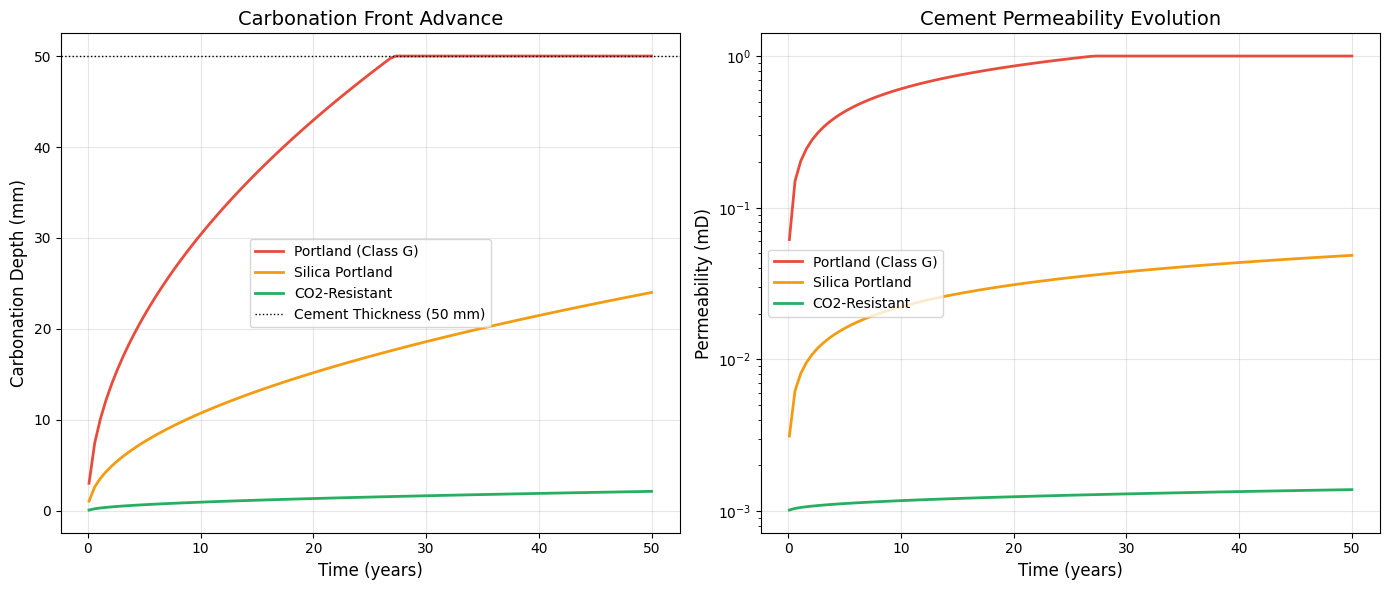

Portland (Class G)       : Full carbonation in 27.1 years
Silica Portland          : Full carbonation in 216.8 years
CO2-Resistant            : Full carbonation in 27104.0 years


In [9]:
cement_types = [
    (CementDegradationModel.CementType.PORTLAND, "Portland (Class G)"),
    (CementDegradationModel.CementType.SILICA_PORTLAND, "Silica Portland"),
    (CementDegradationModel.CementType.CO2_RESISTANT, "CO2-Resistant"),
]

years = np.linspace(0.1, 50.0, 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#e74c3c', '#f39c12', '#27ae60']

for (ctype, label), color in zip(cement_types, colors):
    cement = CementDegradationModel(f"Cement ({label})")
    cement.setCementType(ctype)
    cement.setInitialPermeability(0.001, "mD")
    cement.setCementThickness(0.05, "m")  # 50 mm
    cement.setCO2Conditions(10.0, 273.15 + 60.0)  # 10 bar CO2, 60°C

    depths = [cement.getDegradationDepth(float(y), "mm") for y in years]
    perms = [cement.getPermeabilityAtTime(float(y), "mD") for y in years]

    ax1.plot(years, depths, color=color, linewidth=2, label=label)
    ax2.semilogy(years, perms, color=color, linewidth=2, label=label)

ax1.axhline(y=50.0, color='k', linestyle=':', linewidth=1, label='Cement Thickness (50 mm)')
ax1.set_xlabel('Time (years)', fontsize=12)
ax1.set_ylabel('Carbonation Depth (mm)', fontsize=12)
ax1.set_title('Carbonation Front Advance', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Time (years)', fontsize=12)
ax2.set_ylabel('Permeability (mD)', fontsize=12)
ax2.set_title('Cement Permeability Evolution', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print time to full carbonation for each type
for ctype, label in cement_types:
    cement = CementDegradationModel(f"Cement")
    cement.setCementType(ctype)
    cement.setInitialPermeability(0.001, "mD")
    cement.setCementThickness(0.05, "m")
    cement.setCO2Conditions(10.0, 273.15 + 60.0)
    time_full = cement.getTimeToFullCarbonation("years")
    print(f"{label:25s}: Full carbonation in {time_full:.1f} years")

## 6. Multi-Compartment Reservoir Pressure Response

Model a three-compartment system: target sand, thief zone, and aquifer.
Track how injection into the target zone causes pressure to build and
fluid to cross-flow into adjacent zones.

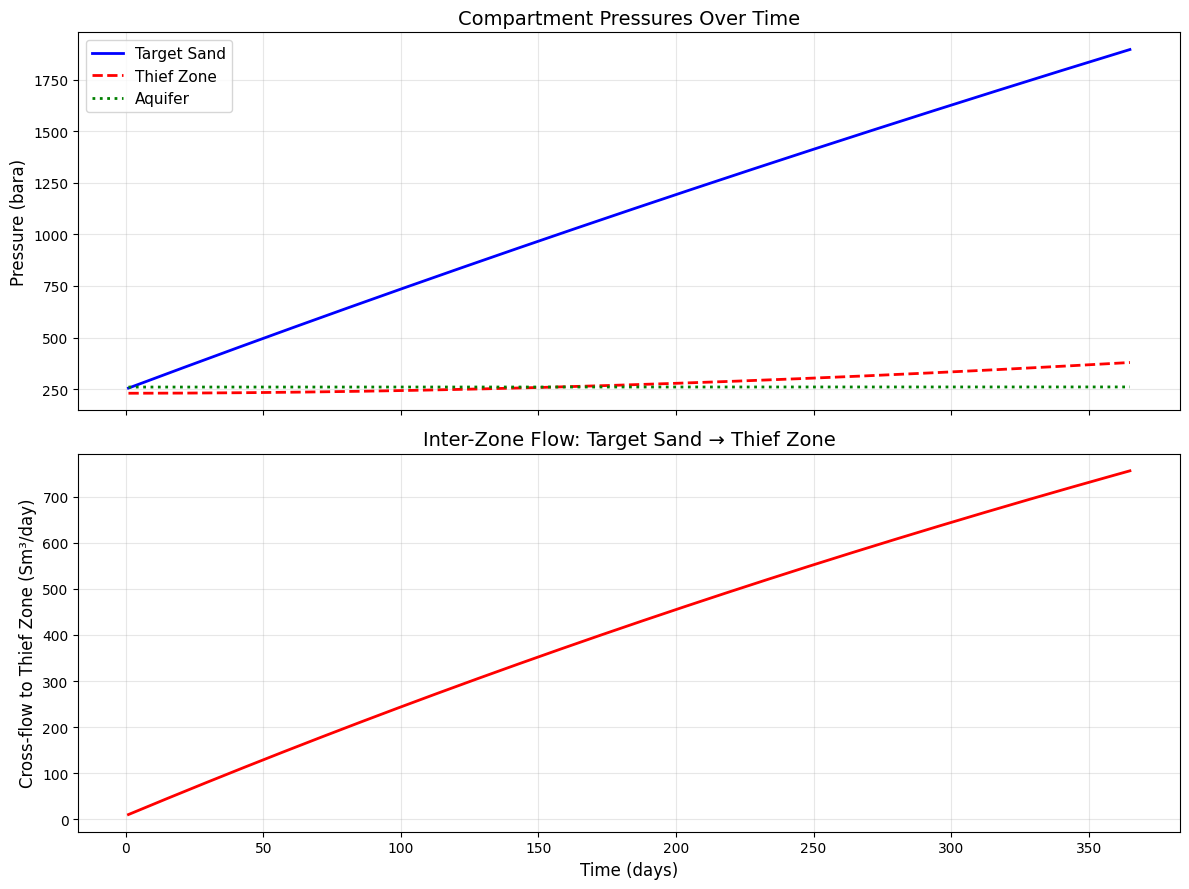

After 365 days of injection at 5000 Sm³/day:
  Target Sand pressure: 1895.4 bara (was 250.0)
  Thief Zone pressure:  379.0 bara (was 230.0)
  Cross-flow rate:      756.5 Sm³/day


In [10]:
# Create fluids for each compartment
target_fluid = SystemSrkEos(273.15 + 80.0, 250.0)
target_fluid.addComponent("water", 1.0)
target_fluid.setMixingRule("classic")

thief_fluid = target_fluid.clone()
aquifer_fluid = target_fluid.clone()

reservoir = MultiCompartmentReservoir("3-Zone Model")

# Add compartments: (name, fluid, pore_volume_m3, initial_pressure_bara)
reservoir.addCompartment("Target Sand", target_fluid, 1.0e7, 250.0)
reservoir.addCompartment("Thief Zone", thief_fluid, 5.0e6, 230.0)
reservoir.addCompartment("Aquifer", aquifer_fluid, 1.0e9, 260.0)

# Compressibility (1/bar)
reservoir.setCompressibility("Target Sand", 1e-4)
reservoir.setCompressibility("Thief Zone", 2e-4)
reservoir.setCompressibility("Aquifer", 5e-5)

# Inter-zone transmissibility (m3/day/bar)
reservoir.setTransmissibility("Target Sand", "Thief Zone", 0.5)
reservoir.setTransmissibility("Target Sand", "Aquifer", 0.1)

# Add injection well
reservoir.addInjectionRate("INJ-1", "Target Sand", 5000.0)  # 5000 Sm3/day

# Time-step for 365 days
n_days = 365
dt = 86400.0  # 1 day in seconds

days = []
p_target = []
p_thief = []
p_aquifer = []
crossflow_to_thief = []

for day in range(n_days):
    reservoir.runTimeStep(dt)
    days.append(day + 1)
    p_target.append(reservoir.getCompartmentPressure("Target Sand", "bara"))
    p_thief.append(reservoir.getCompartmentPressure("Thief Zone", "bara"))
    p_aquifer.append(reservoir.getCompartmentPressure("Aquifer", "bara"))
    crossflow_to_thief.append(
        reservoir.getInterZoneFlowRate("Target Sand", "Thief Zone", "Sm3/day"))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

ax1.plot(days, p_target, 'b-', linewidth=2, label='Target Sand')
ax1.plot(days, p_thief, 'r--', linewidth=2, label='Thief Zone')
ax1.plot(days, p_aquifer, 'g:', linewidth=2, label='Aquifer')
ax1.set_ylabel('Pressure (bara)', fontsize=12)
ax1.set_title('Compartment Pressures Over Time', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(days, crossflow_to_thief, 'r-', linewidth=2)
ax2.set_xlabel('Time (days)', fontsize=12)
ax2.set_ylabel('Cross-flow to Thief Zone (Sm³/day)', fontsize=12)
ax2.set_title('Inter-Zone Flow: Target Sand → Thief Zone', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"After {n_days} days of injection at 5000 Sm³/day:")
print(f"  Target Sand pressure: {p_target[-1]:.1f} bara (was 250.0)")
print(f"  Thief Zone pressure:  {p_thief[-1]:.1f} bara (was 230.0)")
print(f"  Cross-flow rate:      {crossflow_to_thief[-1]:.1f} Sm³/day")

## 7. Injection Conformance Monitoring (Hall Plot)

The Hall plot tracks cumulative (WHP × Δt) vs. cumulative injection volume.
A constant slope indicates stable injectivity. Slope changes indicate:
- **Decreasing slope:** fracture growth or improved injectivity
- **Increasing slope:** plugging, scaling, or skin increase

In [11]:
monitor = InjectionConformanceMonitor("INJ-1 Monitor")

# Simulate 200 days of injection data
np.random.seed(42)

for day in range(200):
    # Base WHP with gradual decrease (simulating fracture growth)
    if day < 80:
        whp = 260.0 + np.random.normal(0, 2)  # stable
        rate = 5000.0 + np.random.normal(0, 100)
    elif day < 120:
        whp = 260.0 - (day - 80) * 0.3 + np.random.normal(0, 2)  # declining WHP
        rate = 5000.0 + (day - 80) * 50 + np.random.normal(0, 100)  # increasing rate
    else:
        whp = 248.0 + np.random.normal(0, 2)  # new stable
        rate = 7000.0 + np.random.normal(0, 100)

    monitor.recordInjectionData(float(day), float(max(whp, 200.0)), float(max(rate, 1000.0)))

# Calculate Hall plot
monitor.calculateHallPlot()

initial_slope = monitor.getInitialHallSlope()
current_slope = monitor.getCurrentHallSlope()
changed = monitor.detectSlopeChange(0.15)  # 15% threshold
diagnosis = str(monitor.getDiagnosis())

print(f"Initial Hall slope: {initial_slope:.4f} bar·day/m³")
print(f"Current Hall slope: {current_slope:.4f} bar·day/m³")
print(f"Slope change detected (15% threshold): {changed}")
print(f"Diagnosis: {diagnosis}")

# Add zone profile
monitor.addZoneProfile("Target Sand", 2500.0, 0.55, True)
monitor.addZoneProfile("Thief Zone", 2600.0, 0.35, False)
monitor.addZoneProfile("Unknown", 2700.0, 0.10, False)

print(f"\nInjection Efficiency: {monitor.getInjectionEfficiency():.1%}")
print(f"Out-of-Zone Fraction: {monitor.getOutOfZoneFraction():.1%}")

Initial Hall slope: 0.0521 bar·day/m³
Current Hall slope: 0.0355 bar·day/m³
Slope change detected (15% threshold): True
Diagnosis: FRACTURE_GROWTH: Hall slope decreased — possible fracture growth or improved injectivity. Risk of out-of-zone fracture extension.

Injection Efficiency: 55.0%
Out-of-Zone Fraction: 45.0%


## 8. Integrated Risk Assessment

Combine the models to evaluate the total out-of-zone risk for a CO2 injection well
over a 30-year injection period.

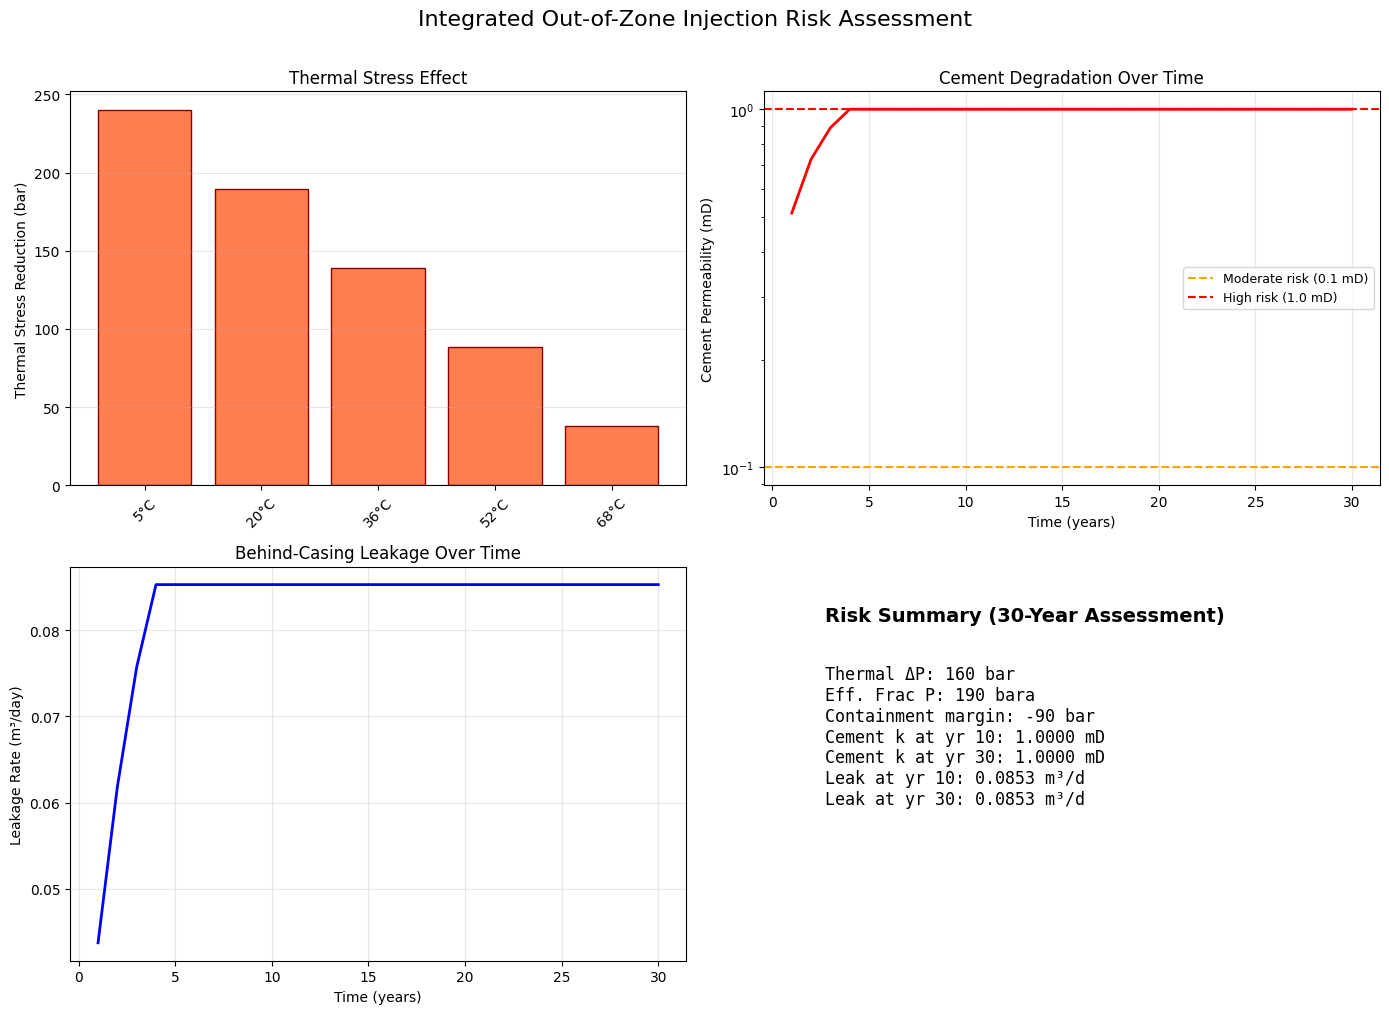

In [12]:
# --- Parameters ---
T_inj_C = 30.0        # Injection temperature
T_res_C = 80.0        # Reservoir temperature
P_res = 250.0         # Reservoir pressure (bara)
P_frac = 350.0        # Original fracture pressure (bara)
barrier_stress = 20.0 # Barrier stress contrast (bar)
cement_thickness_mm = 50.0
injection_years = 30

# 1. Thermal stress effect
model = InjectionWellModel()
model.setFracturePressure(P_frac, "bara")
model.setMaxBHP(P_frac, "bara")
model.setDrainageRadius(500.0)
model.setWellboreRadius(0.1)
model.setThermalStressReduction(273.15 + T_inj_C, 273.15 + T_res_C, 1.2e-5, 20.0)
model.setPoissonsRatio(0.25)

thermal_reduction = model.getThermalStressReduction()
effective_frac_p = model.getEffectiveFracturePressure()

# 2. Cement degradation over time
cement = CementDegradationModel("Injection Cement")
cement.setCementType(CementDegradationModel.CementType.PORTLAND)
cement.setInitialPermeability(0.001, "mD")
cement.setCementThickness(cement_thickness_mm / 1000.0, "m")
cement.setCO2Conditions(10.0, 273.15 + T_res_C)

# 3. Evolving leakage over time
years_arr = np.arange(1, injection_years + 1, dtype=float)
perm_evolution = []
leakage_evolution = []

leakage = AnnularLeakagePath("cement path")
leakage.setLeakageMechanism(AnnularLeakagePath.LeakageMechanism.POROUS_CEMENT)
leakage.setPathGeometry(1500.0, 1600.0, 0.10, 0.0005)
leakage.setCementCrossSectionArea(0.02)
leakage.setFluidViscosity(0.001)

for y in years_arr:
    k = cement.getPermeabilityAtTime(float(y), "mD")
    perm_evolution.append(k)

    # Update leakage model with degraded permeability
    leakage.setCementPermeability(k, "mD")
    leakage.calculate(300.0, P_res)  # injection pressure 300 bara
    leakage_evolution.append(leakage.getCementLeakageRate("m3/day"))

# Summary plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Thermal stress effect
ax = axes[0, 0]
temps = np.linspace(5, 80, 20)
reductions = []
for t in temps:
    model.setThermalStressReduction(273.15 + t, 273.15 + T_res_C, 1.2e-5, 20.0)
    reductions.append(model.getThermalStressReduction())
ax.bar([f"{int(t)}°C" for t in temps[::4]], reductions[::4], color='coral', edgecolor='darkred')
ax.set_ylabel('Thermal Stress Reduction (bar)')
ax.set_title('Thermal Stress Effect')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Top-right: Cement permeability evolution
ax = axes[0, 1]
ax.semilogy(years_arr, perm_evolution, 'r-', linewidth=2)
ax.axhline(y=0.1, color='orange', linestyle='--', label='Moderate risk (0.1 mD)')
ax.axhline(y=1.0, color='red', linestyle='--', label='High risk (1.0 mD)')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Cement Permeability (mD)')
ax.set_title('Cement Degradation Over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom-left: Leakage rate evolution
ax = axes[1, 0]
ax.plot(years_arr, leakage_evolution, 'b-', linewidth=2)
ax.set_xlabel('Time (years)')
ax.set_ylabel('Leakage Rate (m³/day)')
ax.set_title('Behind-Casing Leakage Over Time')
ax.grid(True, alpha=0.3)

# Bottom-right: Risk summary
ax = axes[1, 1]
risk_items = [
    f"Thermal ΔP: {thermal_reduction:.0f} bar",
    f"Eff. Frac P: {effective_frac_p:.0f} bara",
    f"Containment margin: {effective_frac_p - 300 + barrier_stress:.0f} bar",
    f"Cement k at yr 10: {perm_evolution[9]:.4f} mD",
    f"Cement k at yr 30: {perm_evolution[-1]:.4f} mD",
    f"Leak at yr 10: {leakage_evolution[9]:.4f} m³/d",
    f"Leak at yr 30: {leakage_evolution[-1]:.4f} m³/d",
]
ax.axis('off')
table_text = "\n".join(risk_items)
ax.text(0.1, 0.9, "Risk Summary (30-Year Assessment)",
        transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')
ax.text(0.1, 0.75, table_text, transform=ax.transAxes, fontsize=12,
        va='top', family='monospace')

plt.suptitle('Integrated Out-of-Zone Injection Risk Assessment', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated NeqSim's out-of-zone injection modeling capabilities:

| Class | Purpose | Key Output |
|-------|---------|------------|
| `WellFlow` (injection mode) | Multi-zone rate allocation | Injection efficiency, OOZ rate |
| `WellFlow.ReservoirLayer` | Fracture containment | Safety margin (bar) |
| `InjectionWellModel` | Thermal stress + multi-zone | Effective frac pressure |
| `AnnularLeakagePath` | Behind-casing leakage | Leakage rate (m³/day) |
| `CementDegradationModel` | CO2 cement degradation | Permeability over time |
| `MultiCompartmentReservoir` | Inter-zone communication | Cross-flow rates |
| `InjectionConformanceMonitor` | Hall plot diagnostics | Conformance diagnosis |

### Further Reading

- [Out-of-Zone Injection Documentation](../../docs/process/out_of_zone_injection.md)
- [CO2 Injection Well Analysis](../../docs/process/co2_injection_well_analysis.md)
- [Well Mechanical Design](../../docs/process/well_mechanical_design.md)